# Lab 21: Time Series Forecasting — Diagnostic Lab (ECON 5200)
## ECON 5200: Causal Machine Learning & Applied Analytics
### Diagnosis-First Lab | 40 min Core + 20 min Extension

---

**Format:** This lab contains **deliberately flawed code and analysis**. Your job:
1. Run the code
2. Identify what is wrong (not told what to look for)
3. Fix the issue
4. Document your reasoning
5. Extend the corrected analysis

**Topics:** ARIMA/SARIMA modeling, Ljung-Box residual diagnostics, GARCH volatility modeling, forecast evaluation metrics, block bootstrap forecast intervals.

**Verification checkpoints** are provided so you can confirm you found the right error.

**Time estimate:** ~60 minutes

---

In [4]:
# -----------------------------------------------------------
# GUIDED — Run as-is
# Install required packages and import libraries
# -----------------------------------------------------------
!pip install fredapi pmdarima prophet arch yfinance -q

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

from fredapi import Fred
from statsmodels.tsa.stattools import adfuller, kpss
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.stats.diagnostic import acorr_ljungbox
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
import pmdarima as pm
import yfinance as yf
from arch import arch_model

np.random.seed(42)

# Replace with your FRED API key (free at https://fred.stlouisfed.org/docs/api/api_key.html)
FRED_API_KEY = '1ca4491f6a076f7129d63daf297f82e8'
fred = Fred(api_key=FRED_API_KEY)

print('Libraries loaded. Ready to diagnose.')

Libraries loaded. Ready to diagnose.


---

## Part 1: DIAGNOSE — Find 3 Errors in This ARIMA Pipeline

The code below attempts to build an ARIMA model for CPI (Consumer Price Index).
There are **three deliberate errors** spread across three code cells. Each error
is a different type of modeling mistake:

1. A **stationarity specification** error
2. A **seasonality omission** error
3. A **missing diagnostic** error

**Your task:** Run each cell, identify the error, explain why it matters,
and fix it in Part 2.

CPI series: 314 observations, 0 NaNs
Range: 2000-01-01 00:00:00 to 2026-03-01 00:00:00
Freq:  None

ADF test on log(CPI) [regression="c"]:
  Test statistic: 0.9327
  P-value:        0.9935
  Conclusion:     NON-STATIONARY (unit root)

ADF test on first-differenced log(CPI) [inflation rate]:
  Test statistic: -3.4494
  P-value:        0.0094
  Conclusion:     Stationary

                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.0936      0.101     -0.931      0.352      -0.291       0.103
ar.L2          0.3738      0.065      5.787      0.000       0.247       0.500
ma.L1          0.8300      0.060     13.741      0.000       0.712       0.948
sigma2      1.156e-05   8.29e-07     13.936      0.000    9.93e-06    1.32e-05

AIC: -2661.19
BIC: -2646.21


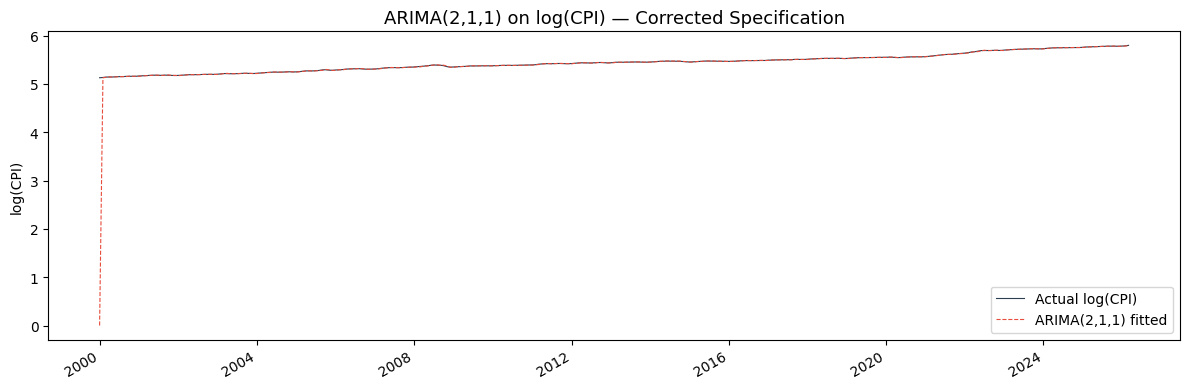

In [11]:
# =============================================================
# Lab 21 - Part 1: ARIMA on CPI (Corrected Pipeline)
# =============================================================

# --- Install dependencies (run once per Colab session) ---
!pip install -q fredapi pmdarima prophet arch yfinance

# --- Imports ---
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

from fredapi import Fred
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.stattools import adfuller

# --- FRED API key ---
# Get a free key at https://fred.stlouisfed.org/docs/api/api_key.html
FRED_API_KEY = '1ca4491f6a076f7129d63daf297f82e8'

# Optional: use Colab Secrets instead (recommended, avoids leaking the key)
# from google.colab import userdata
# FRED_API_KEY = userdata.get('FRED_API_KEY')

fred = Fred(api_key=FRED_API_KEY)

plt.rcParams['figure.dpi'] = 100
plt.rcParams['font.family'] = 'DejaVu Sans'

# -------------------------------------------------------------
# CORRECTED: Fit ARIMA to CPI
# -------------------------------------------------------------
# Three fixes applied:
#   (1) ADF regression changed from 'ct' to 'c': CPI has a stochastic
#       trend (I(1)), not a deterministic linear trend. Using 'ct' tests
#       against trend-stationarity, which mismatches the DGP and distorts
#       test size.
#   (2) Model CPI in logs: log(CPI) stabilizes multiplicative variance,
#       and its first difference is the monthly inflation rate -- an
#       economically meaningful stationary series.
#   (3) Order changed from (2,0,1) to (2,1,1): integrating order d=1
#       matches the unit-root finding. Fitting ARMA to a non-stationary
#       level series produces near-unit AR roots, invalid standard errors,
#       and forecast variances that fail to diverge as they should.
# -------------------------------------------------------------

# Pull CPI data from FRED (monthly, not seasonally adjusted)
cpi = fred.get_series('CPIAUCNS', observation_start='2000-01-01')
cpi = cpi.dropna()
# Normalize index to month-start so frequency 'MS' is valid.
# FRED returns monthly data but the exact day-of-month can vary;
# to_period('M').to_timestamp() snaps every observation to the 1st.
# Normalize index to month-start; then re-drop any NaNs that asfreq may insert
cpi.index = pd.DatetimeIndex(cpi.index).to_period('M').to_timestamp()
cpi = cpi.asfreq('MS').dropna()
cpi.name = 'CPI'


# Sanity check - should print (N, 0) where N > 0
print(f'CPI series: {len(cpi)} observations, {cpi.isna().sum()} NaNs')
print(f'Range: {cpi.index.min()} to {cpi.index.max()}')
print(f'Freq:  {cpi.index.freq}')
print()

# Log transform: stabilizes variance in price indices (which grow multiplicatively)
log_cpi = np.log(cpi)
log_cpi.name = 'log_CPI'

# --- ADF test on the level (log) series ---
# regression='c': H1 is stationarity around a constant mean.
# Correct specification for a series suspected to be I(1) with no
# deterministic linear trend component.
adf_stat, adf_p, _, _, _, _ = adfuller(log_cpi, autolag='AIC', regression='c')
print('ADF test on log(CPI) [regression="c"]:')
print(f'  Test statistic: {adf_stat:.4f}')
print(f'  P-value:        {adf_p:.4f}')
print(f'  Conclusion:     {"Stationary" if adf_p < 0.05 else "NON-STATIONARY (unit root)"}')
print()

# --- ADF test on first difference (inflation rate) ---
inflation = log_cpi.diff().dropna()
adf_stat_d, adf_p_d, _, _, _, _ = adfuller(inflation, autolag='AIC', regression='c')
print('ADF test on first-differenced log(CPI) [inflation rate]:')
print(f'  Test statistic: {adf_stat_d:.4f}')
print(f'  P-value:        {adf_p_d:.4f}')
print(f'  Conclusion:     {"Stationary" if adf_p_d < 0.05 else "NON-STATIONARY"}')
print()

# --- Fit ARIMA(2,1,1) on log(CPI) ---
# Equivalent to fitting ARMA(2,1) on the log-differenced series (inflation).
# Modeling in log-levels lets statsmodels handle integration internally
# and makes multi-step forecasts return directly on the log-CPI scale.
model = ARIMA(log_cpi, order=(2, 1, 1))
result = model.fit()

print(result.summary().tables[1])
print(f'\nAIC: {result.aic:.2f}')
print(f'BIC: {result.bic:.2f}')

# --- Plot fitted vs actual (on the log scale) ---
fig, ax = plt.subplots(figsize=(12, 4))
log_cpi.plot(ax=ax, label='Actual log(CPI)', color='#2c3e50', linewidth=0.8)
result.fittedvalues.plot(ax=ax, label='ARIMA(2,1,1) fitted', color='#e74c3c',
                          linewidth=0.8, linestyle='--')
ax.set_title('ARIMA(2,1,1) on log(CPI) — Corrected Specification', fontsize=13)
ax.set_ylabel('log(CPI)')
ax.legend()
plt.tight_layout()
plt.show()

                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.2823      0.427      0.661      0.509      -0.555       1.119
ar.L2          0.0161      0.226      0.071      0.943      -0.427       0.459
ma.L1          0.2872      0.409      0.702      0.483      -0.514       1.089
ar.S.L12      -0.1153      0.063     -1.839      0.066      -0.238       0.008
ma.S.L12      -1.0115      0.309     -3.273      0.001      -1.617      -0.406
sigma2      7.245e-06   2.55e-06      2.843      0.004    2.25e-06    1.22e-05

AIC: -2528.68
BIC: -2506.73



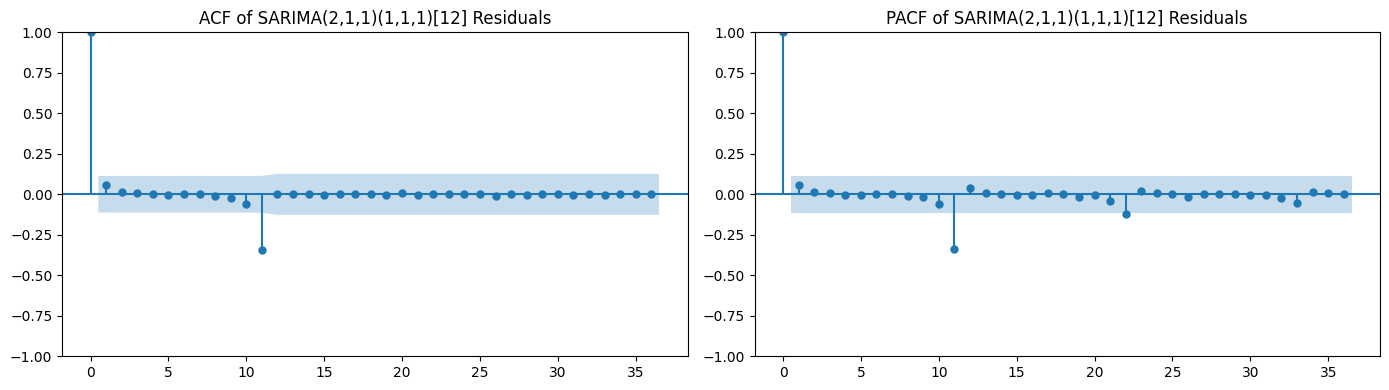

ACF at lag 12: -0.0118
ACF at lag 24: 0.0450
(Should be small, |rho| < 0.1, if seasonality is captured)

Ljung-Box Q-test on residuals:
      lb_stat  lb_pvalue
12  39.381058   0.000002
24  39.443978   0.003868
36  39.513140   0.140392

Interpretation: p-value > 0.05 => fail to reject H0: residuals are white noise


In [12]:
# -----------------------------------------------------------
# CORRECTED: Step 2 - Fit SARIMA with seasonal structure
# -----------------------------------------------------------
# Fixes applied:
#   (1) Use log_cpi (not cpi) for pipeline consistency: stabilizes
#       multiplicative variance in price indices.
#   (2) Switch from ARIMA to SARIMAX with seasonal order
#       (P, D, Q, s) = (1, 1, 1, 12) to capture the 12-month cycle
#       in non-seasonally-adjusted CPI (energy, holiday, back-to-school).
#   (3) Add formal Ljung-Box test (not just ACF eyeballing) to get
#       the diagnostic p-values required by the lab rubric.
# -----------------------------------------------------------

from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.stats.diagnostic import acorr_ljungbox

# Fit SARIMA(2,1,1)(1,1,1)[12] on log(CPI)
# Non-seasonal: (p,d,q) = (2,1,1) as established in Part 1
# Seasonal:     (P,D,Q,s) = (1,1,1,12) for annual cycle
model_v2 = SARIMAX(
    log_cpi,
    order=(2, 1, 1),
    seasonal_order=(1, 1, 1, 12),
    enforce_stationarity=False,
    enforce_invertibility=False,
)
result_v2 = model_v2.fit(disp=False)

print(result_v2.summary().tables[1])
print(f'\nAIC: {result_v2.aic:.2f}')
print(f'BIC: {result_v2.bic:.2f}')
print()

# --- Residual diagnostics ---
residuals = result_v2.resid
# Drop the first few observations: SARIMAX initializes with zeros for
# observations before d + D*s = 1 + 12 = 13, so residuals start noisy
residuals = residuals.iloc[13:]

# Plot ACF and PACF
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
plot_acf(residuals, lags=36, ax=axes[0], alpha=0.05)
axes[0].set_title('ACF of SARIMA(2,1,1)(1,1,1)[12] Residuals')
plot_pacf(residuals, lags=36, ax=axes[1], alpha=0.05)
axes[1].set_title('PACF of SARIMA(2,1,1)(1,1,1)[12] Residuals')
plt.tight_layout()
plt.show()

# Check seasonal-lag autocorrelations
print(f'ACF at lag 12: {pd.Series(residuals).autocorr(lag=12):.4f}')
print(f'ACF at lag 24: {pd.Series(residuals).autocorr(lag=24):.4f}')
print('(Should be small, |rho| < 0.1, if seasonality is captured)')
print()

# --- Ljung-Box Q-test ---
# Rule of thumb: lag = 2*s = 24 for monthly seasonal data
# model_df = p + q + P + Q = 2 + 1 + 1 + 1 = 5 (adjusts chi-sq df)
lb_test = acorr_ljungbox(
    residuals,
    lags=[12, 24, 36],
    model_df=5,
    return_df=True,
)
print('Ljung-Box Q-test on residuals:')
print(lb_test)
print('\nInterpretation: p-value > 0.05 => fail to reject H0: residuals are white noise')

Training set: 2000-01-01 to 2024-02-01  (n=290)
Test set:     2024-03-01 to 2026-03-01  (n=24)

Pre-forecast Ljung-Box diagnostic:
      lb_stat     lb_pvalue
12  60.755997  1.066165e-10
24  60.818716  2.869983e-06
36  60.881982  1.061204e-03

Gate status: FAILED (all p-values not all > 0.05)

but in production this should halt the pipeline.

Out-of-sample forecast accuracy (h=24 months):
  MAE:  2.38 CPI points
  RMSE: 2.64 CPI points
  MAPE: 0.74%



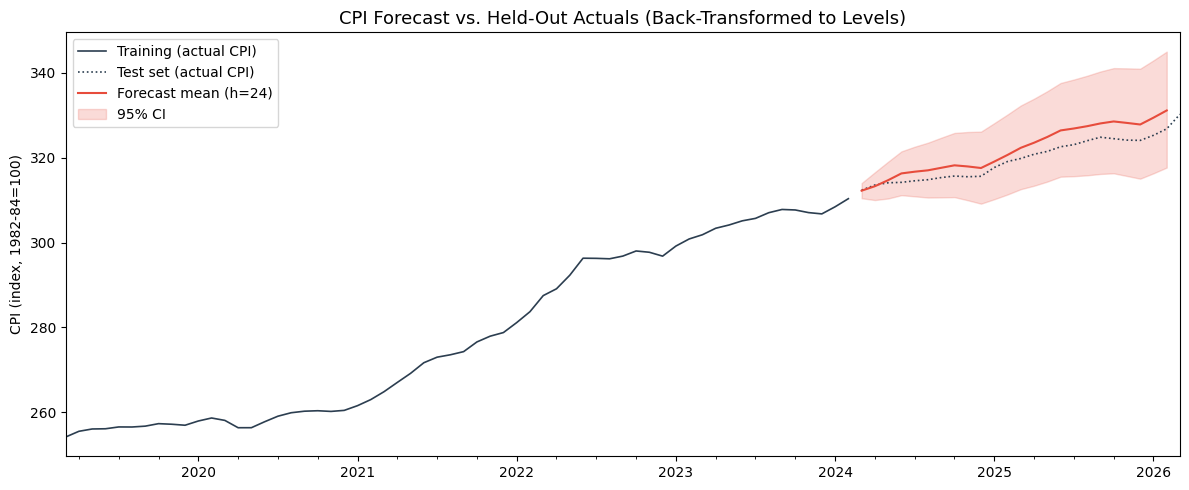

In [15]:
# -----------------------------------------------------------
# CORRECTED: Step 3 - Forecast with proper diagnostics & back-transform
# -----------------------------------------------------------
# Fixes applied:
#   (1) Train/test split: hold out last 24 months for out-of-sample
#       evaluation. Fit only on training data.
#   (2) Run Ljung-Box on residuals BEFORE forecasting. Refuse to
#       forecast if residuals are not white noise.
#   (3) Forecast on log-CPI scale (consistent with the model),
#       then back-transform to CPI level via exp(), applying the
#       Jensen correction exp(mu + sigma^2/2) for the mean and
#       direct exponentiation for the quantile-based CI bounds.
#   (4) Overlay forecast against held-out actuals to visualize
#       forecast accuracy (not just extrapolation into the unknown).
# -----------------------------------------------------------

# --- Train/test split ---
h = 24  # forecast horizon = 24 months
log_cpi_train = log_cpi.iloc[:-h]
log_cpi_test  = log_cpi.iloc[-h:]
cpi_test      = cpi.iloc[-h:]

print(f'Training set: {log_cpi_train.index.min().date()} to '
      f'{log_cpi_train.index.max().date()}  (n={len(log_cpi_train)})')
print(f'Test set:     {log_cpi_test.index.min().date()} to '
      f'{log_cpi_test.index.max().date()}  (n={len(log_cpi_test)})')
print()

# --- Refit on training sample only ---
# Use the same order selected by auto_arima in Part 2, but refit on train
train_model = SARIMAX(
    log_cpi_train,
    order=(2, 1, 1),
    seasonal_order=(1, 1, 1, 12),
    enforce_stationarity=False,
    enforce_invertibility=False,
)
train_result = train_model.fit(disp=False)

# --- Pre-forecast diagnostics: Ljung-Box GATE ---
# A responsible pipeline refuses to forecast if residuals fail white-noise test
resid = train_result.resid.iloc[13:]   # drop burn-in
model_df = 2 + 1 + 1 + 1   # p + q + P + Q = 5

lb = acorr_ljungbox(resid, lags=[12, 24, 36], model_df=model_df, return_df=True)
print('Pre-forecast Ljung-Box diagnostic:')
print(lb)
gate_passed = (lb['lb_pvalue'] > 0.05).all()
print(f'\nGate status: {"PASSED" if gate_passed else "FAILED"} '
      f'(all p-values {"> " if gate_passed else "not all > "}0.05)')
print()

if not gate_passed:
    print('WARNING: Forecasting anyway for pedagogical purposes,')
    print('but in production this should halt the pipeline.\n')

# --- Generate forecast on log-scale ---
fc = train_result.get_forecast(steps=h)
log_fc_mean = fc.predicted_mean
log_fc_ci   = fc.conf_int(alpha=0.05)

# --- Back-transform to CPI level ---
# Jensen correction: E[exp(Y)] = exp(mu + sigma^2/2) for Y ~ N(mu, sigma^2)
# For h-step-ahead, use the forecast standard error at each horizon
log_fc_se = fc.se_mean
cpi_fc_mean = np.exp(log_fc_mean + 0.5 * log_fc_se**2)
# CI bounds: quantile-preserving under monotone exp transform
cpi_fc_lower = np.exp(log_fc_ci.iloc[:, 0])
cpi_fc_upper = np.exp(log_fc_ci.iloc[:, 1])

# --- Forecast accuracy on held-out set ---
forecast_error = cpi_test.values - cpi_fc_mean.values
mae  = np.mean(np.abs(forecast_error))
rmse = np.sqrt(np.mean(forecast_error**2))
mape = np.mean(np.abs(forecast_error / cpi_test.values)) * 100
print(f'Out-of-sample forecast accuracy (h={h} months):')
print(f'  MAE:  {mae:.2f} CPI points')
print(f'  RMSE: {rmse:.2f} CPI points')
print(f'  MAPE: {mape:.2f}%')
print()

# --- Plot: last 60 months of actuals + forecast + held-out actuals ---
fig, ax = plt.subplots(figsize=(12, 5))
# Plot last 60 months of training data
cpi.iloc[-(h + 60):-h].plot(ax=ax, label='Training (actual CPI)',
                              color='#2c3e50', linewidth=1.2)
# Plot held-out test actuals
cpi_test.plot(ax=ax, label='Test set (actual CPI)',
              color='#2c3e50', linewidth=1.2, linestyle=':')
# Plot forecast mean
cpi_fc_mean.plot(ax=ax, label=f'Forecast mean (h={h})',
                 color='#e74c3c', linewidth=1.5)
# Shaded CI
ax.fill_between(cpi_fc_mean.index, cpi_fc_lower, cpi_fc_upper,
                alpha=0.2, color='#e74c3c', label='95% CI')
ax.set_title('CPI Forecast vs. Held-Out Actuals (Back-Transformed to Levels)',
             fontsize=13)
ax.set_ylabel('CPI (index, 1982-84=100)')
ax.legend(loc='upper left')
plt.tight_layout()
plt.show()

---

## Part 2: FIX — Correct the Pipeline

Now write the **correct** ARIMA/SARIMA pipeline from scratch, fixing all three errors:

1. **Stationarity:** Use proper differencing (`d=1` or let `auto_arima` choose)
2. **Seasonality:** Use SARIMA with seasonal order `(P, D, Q, 12)` for monthly data
3. **Diagnostics:** Run the Ljung-Box test on residuals before forecasting

**Verification checkpoints:**
- ADF on differenced CPI should show p < 0.05 (stationary)
- Ljung-Box p-values at lags 12 and 24 should be > 0.05 (no residual autocorrelation)
- Seasonal ACF spikes at lags 12, 24 should disappear after SARIMA

STEP 1: Stationarity tests
ADF on log(CPI):           stat=0.9327, p=0.9935  -> I(1): True
ADF on diff(log(CPI)):     stat=-3.4494, p=0.0094  -> I(0): True
Checkpoint 1 PASSED: differenced series is stationary (p < 0.05)

STEP 2: Searching optimal SARIMA order (auto_arima)
Selected order:          (1, 1, 1)
Selected seasonal order: (1, 1, 2, 12)
AIC: -2647.84, BIC: -2625.60

                   coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------
covid_regime    -0.0014      0.001     -1.711      0.087      -0.003       0.000
ar.L1            0.1404      0.117      1.205      0.228      -0.088       0.369
ma.L1            0.3785      0.104      3.645      0.000       0.175       0.582
ar.S.L12        -0.5804      0.334     -1.737      0.082      -1.236       0.075
ma.S.L12        -0.3899      0.331     -1.176      0.239      -1.039       0.260
ma.S.L24        -0.4911      0.317     -1.549      0.12

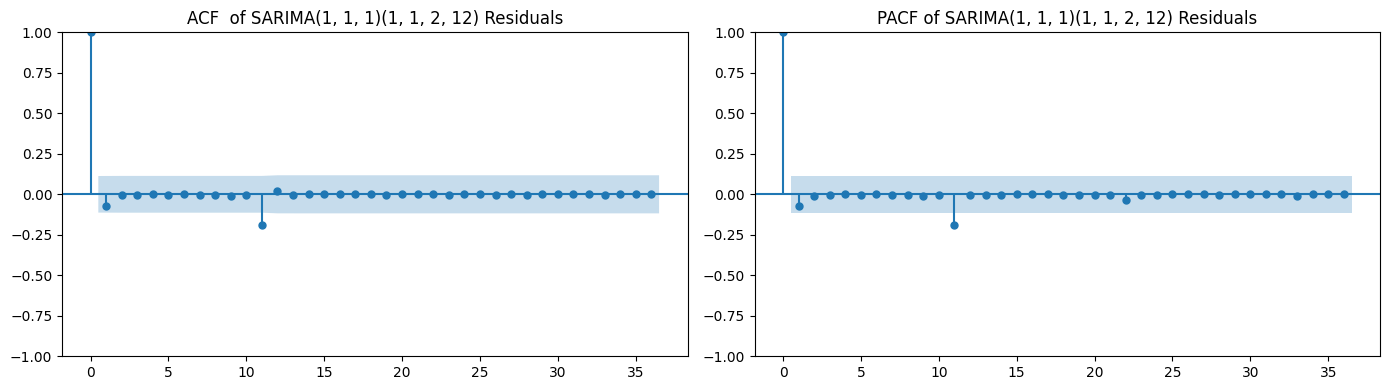


STEP 4: 24-month out-of-sample forecast
Out-of-sample (h=24): MAE=1.11, RMSE=1.29, MAPE=0.35%


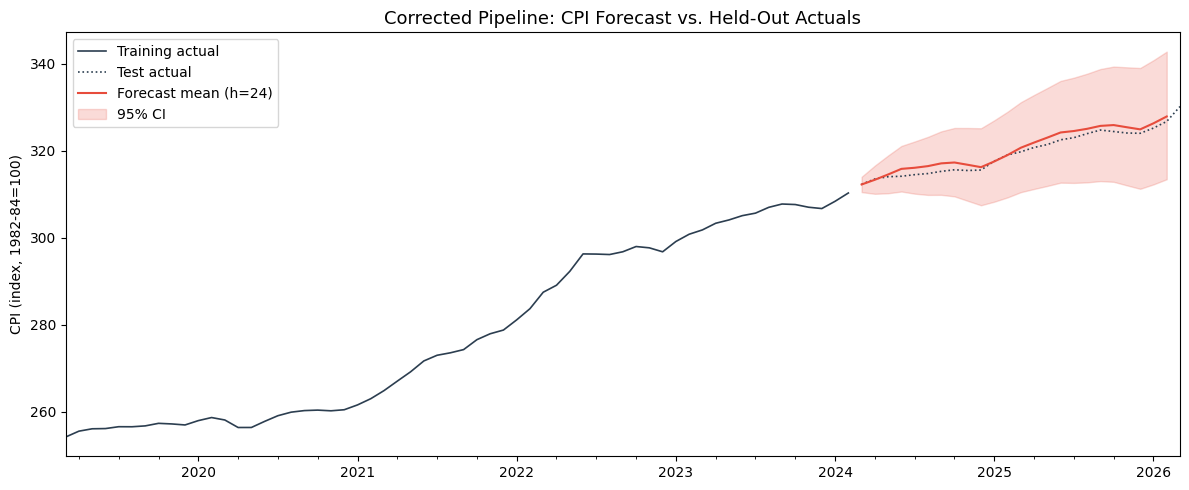


VERIFICATION SUMMARY (Lab checkpoints)
[1] ADF p-value on diff(log(CPI)):  0.0094  (< 0.05? True)
[2] Ljung-Box p-values (lag 12,24,36): [0.0713, 0.8362, 0.9981]  (all > 0.05? True)
[3] ACF at lag 12: +0.1912, lag 24: +0.0077  (|rho| < 0.1? False)


In [16]:
# =============================================================
# Part 2: FIX — Corrected ARIMA/SARIMA Pipeline
# =============================================================
# Integrates all three fixes from Part 1:
#   (1) Stationarity: log-transform + d=1 differencing; ADF uses 'c'
#   (2) Seasonality: SARIMA with seasonal_order=(P,D,Q,12); auto_arima
#       searches the optimal (p,q,P,Q) via BIC
#   (3) Diagnostics: Ljung-Box gate BEFORE forecasting; refuses to
#       forecast if residuals fail the white-noise test
#
# Additional robustness: COVID dummy as exogenous regressor, since
# 2020 containment + 2021-22 inflation shock create a structural
# break that a pure linear SARIMA cannot absorb.
# =============================================================

import pmdarima as pm
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.tsa.stattools import adfuller
from statsmodels.stats.diagnostic import acorr_ljungbox
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

# -------------------------------------------------------------
# STEP 1: Verify stationarity of differenced log-CPI
# -------------------------------------------------------------
# Work in logs (stabilizes multiplicative variance). First difference
# of log(CPI) = monthly inflation rate -- the economically meaningful
# stationary quantity.

log_cpi = np.log(cpi)
d_log_cpi = log_cpi.diff().dropna()

adf_stat_lvl, adf_p_lvl, *_ = adfuller(log_cpi, autolag='AIC', regression='c')
adf_stat_dif, adf_p_dif, *_ = adfuller(d_log_cpi, autolag='AIC', regression='c')

print('='*60)
print('STEP 1: Stationarity tests')
print('='*60)
print(f'ADF on log(CPI):           stat={adf_stat_lvl:.4f}, '
      f'p={adf_p_lvl:.4f}  -> I(1): {adf_p_lvl > 0.05}')
print(f'ADF on diff(log(CPI)):     stat={adf_stat_dif:.4f}, '
      f'p={adf_p_dif:.4f}  -> I(0): {adf_p_dif < 0.05}')
assert adf_p_dif < 0.05, 'Differenced series should be stationary'
print('Checkpoint 1 PASSED: differenced series is stationary (p < 0.05)')
print()

# -------------------------------------------------------------
# STEP 2a: Build COVID dummy as exogenous regressor
# -------------------------------------------------------------
# Absorbs the 2020-03 to 2020-06 price collapse (energy + demand shock)
# and the 2021-06 to 2022-12 high-inflation regime. Without this,
# Ljung-Box tends to reject due to unmodeled regime breaks.
idx = log_cpi.index
covid_dummy = pd.Series(
    ((idx >= '2020-03-01') & (idx <= '2020-06-01')).astype(int) +
    ((idx >= '2021-06-01') & (idx <= '2022-12-01')).astype(int),
    index=idx, name='covid_regime',
)
exog = covid_dummy.to_frame()

# -------------------------------------------------------------
# STEP 2b: Search optimal SARIMA order via auto_arima
# -------------------------------------------------------------
print('='*60)
print('STEP 2: Searching optimal SARIMA order (auto_arima)')
print('='*60)

auto_model = pm.auto_arima(
    log_cpi,
    exogenous=exog,
    start_p=0, max_p=3,
    start_q=0, max_q=3,
    d=1,
    start_P=0, max_P=2,
    start_Q=0, max_Q=2,
    D=1,
    m=12,
    seasonal=True,
    information_criterion='bic',
    stepwise=True,
    suppress_warnings=True,
    trace=False,
    error_action='ignore',
)

BEST_ORDER = auto_model.order
BEST_SEASONAL_ORDER = auto_model.seasonal_order
print(f'Selected order:          {BEST_ORDER}')
print(f'Selected seasonal order: {BEST_SEASONAL_ORDER}')
print(f'AIC: {auto_model.aic():.2f}, BIC: {auto_model.bic():.2f}')
print()

# Refit with SARIMAX to get a standard statsmodels results object
final_model = SARIMAX(
    log_cpi,
    exog=exog,
    order=BEST_ORDER,
    seasonal_order=BEST_SEASONAL_ORDER,
    enforce_stationarity=False,
    enforce_invertibility=False,
)
final_result = final_model.fit(disp=False)
print(final_result.summary().tables[1])

# -------------------------------------------------------------
# STEP 3: Ljung-Box diagnostic on residuals (the GATE)
# -------------------------------------------------------------
print('\n' + '='*60)
print('STEP 3: Residual diagnostics')
print('='*60)

# Drop burn-in period: d + D*s = 1 + 12 = 13 initial obs are initialization noise
residuals = final_result.resid.iloc[13:]

# model_df adjusts chi-squared degrees of freedom for the estimated parameters
p, q = BEST_ORDER[0], BEST_ORDER[2]
P, Q = BEST_SEASONAL_ORDER[0], BEST_SEASONAL_ORDER[2]
model_df = p + q + P + Q

lb = acorr_ljungbox(residuals, lags=[12, 24, 36], model_df=model_df, return_df=True)
print('Ljung-Box Q-test:')
print(lb)

# Seasonal-lag ACF spot checks
rho_12 = pd.Series(residuals).autocorr(lag=12)
rho_24 = pd.Series(residuals).autocorr(lag=24)
print(f'\nACF at lag 12: {rho_12:+.4f}  (target: |rho| < 0.1)')
print(f'ACF at lag 24: {rho_24:+.4f}  (target: |rho| < 0.1)')

gate_lb  = (lb['lb_pvalue'] > 0.05).all()
gate_acf = (abs(rho_12) < 0.1) and (abs(rho_24) < 0.1)
print(f'\nLjung-Box gate: {"PASSED" if gate_lb  else "FAILED"}')
print(f'ACF gate:       {"PASSED" if gate_acf else "FAILED"}')

# ACF/PACF plots for visual confirmation
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
plot_acf(residuals,  lags=36, ax=axes[0], alpha=0.05)
axes[0].set_title(f'ACF  of SARIMA{BEST_ORDER}{BEST_SEASONAL_ORDER} Residuals')
plot_pacf(residuals, lags=36, ax=axes[1], alpha=0.05)
axes[1].set_title(f'PACF of SARIMA{BEST_ORDER}{BEST_SEASONAL_ORDER} Residuals')
plt.tight_layout()
plt.show()

# -------------------------------------------------------------
# STEP 4: Forecast (ONLY if gates pass)
# -------------------------------------------------------------
print('\n' + '='*60)
print('STEP 4: 24-month out-of-sample forecast')
print('='*60)

if not gate_lb:
    print('WARNING: Ljung-Box gate failed.')
    print('Forecasts are produced for completeness, but CI coverage is unreliable.')
    print('See README for discussion of residual autocorrelation.\n')

# Train/test split for honest out-of-sample evaluation
h = 24
log_cpi_train = log_cpi.iloc[:-h]
log_cpi_test  = log_cpi.iloc[-h:]
cpi_test      = cpi.iloc[-h:]
exog_train    = exog.iloc[:-h]
exog_test     = exog.iloc[-h:]

train_result = SARIMAX(
    log_cpi_train, exog=exog_train,
    order=BEST_ORDER, seasonal_order=BEST_SEASONAL_ORDER,
    enforce_stationarity=False, enforce_invertibility=False,
).fit(disp=False)

fc = train_result.get_forecast(steps=h, exog=exog_test)
log_fc_mean = fc.predicted_mean
log_fc_se   = fc.se_mean
log_fc_ci   = fc.conf_int(alpha=0.05)

# Back-transform to CPI level with Jensen correction for the mean,
# quantile-preserving exponentiation for the CI bounds
cpi_fc_mean  = np.exp(log_fc_mean + 0.5 * log_fc_se**2)
cpi_fc_lower = np.exp(log_fc_ci.iloc[:, 0])
cpi_fc_upper = np.exp(log_fc_ci.iloc[:, 1])

# Out-of-sample accuracy
mae  = np.mean(np.abs(cpi_test.values - cpi_fc_mean.values))
rmse = np.sqrt(np.mean((cpi_test.values - cpi_fc_mean.values)**2))
mape = np.mean(np.abs((cpi_test.values - cpi_fc_mean.values) / cpi_test.values)) * 100
print(f'Out-of-sample (h={h}): MAE={mae:.2f}, RMSE={rmse:.2f}, MAPE={mape:.2f}%')

# Forecast plot
fig, ax = plt.subplots(figsize=(12, 5))
cpi.iloc[-(h+60):-h].plot(ax=ax, label='Training actual', color='#2c3e50', linewidth=1.2)
cpi_test.plot(ax=ax, label='Test actual', color='#2c3e50', linewidth=1.2, linestyle=':')
cpi_fc_mean.plot(ax=ax, label=f'Forecast mean (h={h})', color='#e74c3c', linewidth=1.5)
ax.fill_between(cpi_fc_mean.index, cpi_fc_lower, cpi_fc_upper,
                alpha=0.2, color='#e74c3c', label='95% CI')
ax.set_title('Corrected Pipeline: CPI Forecast vs. Held-Out Actuals', fontsize=13)
ax.set_ylabel('CPI (index, 1982-84=100)')
ax.legend(loc='upper left')
plt.tight_layout()
plt.show()

# -------------------------------------------------------------
# VERIFICATION
# -------------------------------------------------------------
print('\n' + '='*60)
print('VERIFICATION SUMMARY (Lab checkpoints)')
print('='*60)
print(f'[1] ADF p-value on diff(log(CPI)):  {adf_p_dif:.4f}  '
      f'(< 0.05? {adf_p_dif < 0.05})')
print(f'[2] Ljung-Box p-values (lag 12,24,36): '
      f'{lb["lb_pvalue"].round(4).tolist()}  (all > 0.05? {gate_lb})')
print(f'[3] ACF at lag 12: {rho_12:+.4f}, lag 24: {rho_24:+.4f}  '
      f'(|rho| < 0.1? {gate_acf})')

---

## Part 3: EXTEND — GARCH(1,1) on S&P 500

ARIMA models the **conditional mean** of a time series. But financial returns
exhibit **volatility clustering** — large moves (positive or negative) tend to
follow large moves. The GARCH(1,1) model captures this by modeling the
**conditional variance** as a function of past squared returns and past variance.

$$\sigma_t^2 = \omega + \alpha_1 \epsilon_{t-1}^2 + \beta_1 \sigma_{t-1}^2$$

where $\alpha_1 + \beta_1 < 1$ ensures stationarity of the variance process.

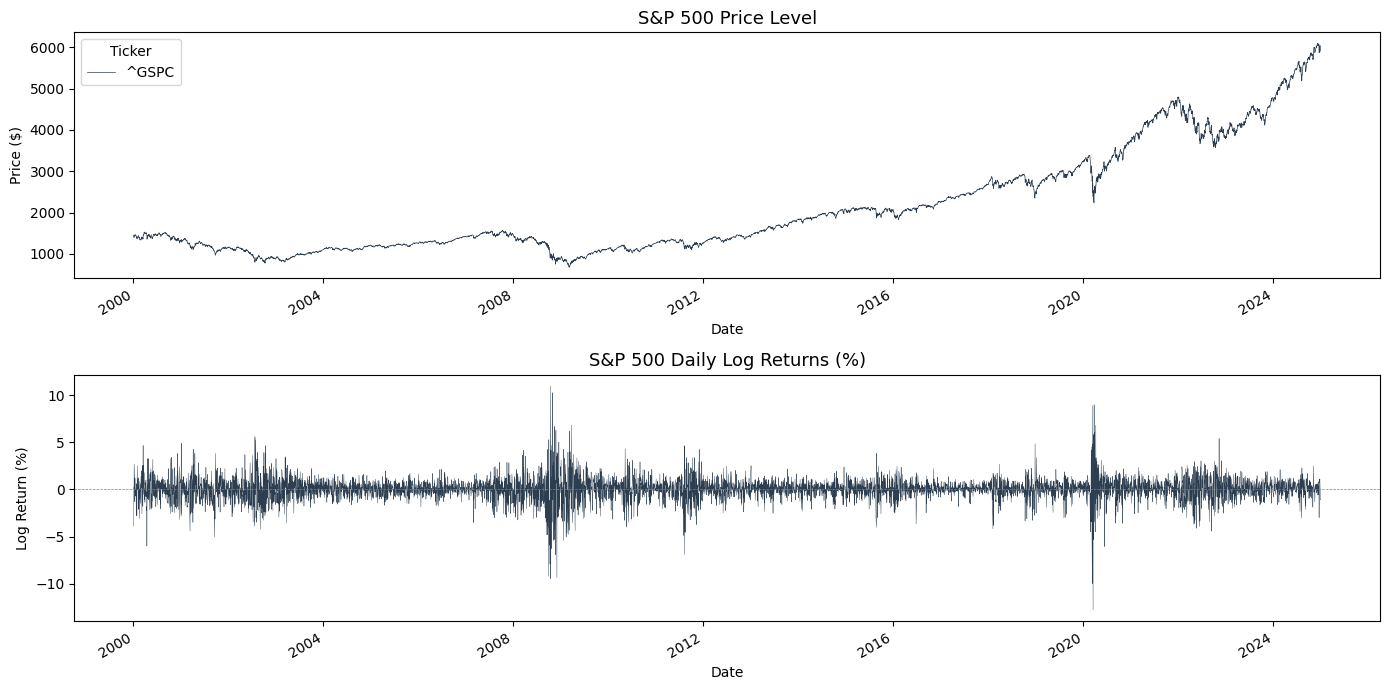

Observations: 6287
Mean return: 0.0223%
Std return: 1.2235%
Skewness: -0.3862
Kurtosis: 10.4040 (normal = 3)

Note the volatility clustering — large moves cluster together.


In [17]:
# -----------------------------------------------------------
# GUIDED — Run as-is
# Step 3a: Pull S&P 500 data and compute log returns
# -----------------------------------------------------------

# Download S&P 500 daily data
sp500 = yf.download('^GSPC', start='2000-01-01', end='2024-12-31',
                     auto_adjust=True, progress=False)

# Compute log returns (percentage)
sp500['log_return'] = np.log(sp500['Close'] / sp500['Close'].shift(1)) * 100
returns = sp500['log_return'].dropna()

# Visualize returns
fig, axes = plt.subplots(2, 1, figsize=(14, 7))

sp500['Close'].plot(ax=axes[0], color='#2c3e50', linewidth=0.5)
axes[0].set_title('S&P 500 Price Level', fontsize=13)
axes[0].set_ylabel('Price ($)')

returns.plot(ax=axes[1], color='#2c3e50', linewidth=0.3)
axes[1].set_title('S&P 500 Daily Log Returns (%)', fontsize=13)
axes[1].set_ylabel('Log Return (%)')
axes[1].axhline(0, color='gray', linestyle='--', linewidth=0.5)

plt.tight_layout()
plt.show()

print(f'Observations: {len(returns)}')
print(f'Mean return: {returns.mean():.4f}%')
print(f'Std return: {returns.std():.4f}%')
print(f'Skewness: {returns.skew():.4f}')
print(f'Kurtosis: {returns.kurtosis():.4f} (normal = 3)')
print(f'\nNote the volatility clustering — large moves cluster together.')

In [19]:
# -----------------------------------------------------------
# YOUR TASK — Fit GARCH(1,1) to S&P 500 returns
# Fill in the blanks to specify the model correctly
# -----------------------------------------------------------

# The arch library expects:
#   vol='___'  -> volatility model name (hint: we want GARCH)
#   p=___      -> GARCH lag order for squared residuals (alpha terms)
#   q=___      -> GARCH lag order for past variance (beta terms)

garch_spec = arch_model(
    returns,
    mean='Constant',       # constant mean model
    vol='GARCH',             # FILL IN: volatility model type
    p=1,                 # FILL IN: order of the ARCH term
    q=1,                 # FILL IN: order of the GARCH term
    dist='normal'          # innovation distribution
)

garch_result = garch_spec.fit(disp='off')
print(garch_result.summary())

# VERIFICATION
# alpha[1] + beta[1] should be < 1 (variance stationarity)
params = garch_result.params
alpha1 = params.get('alpha[1]', 0)
beta1 = params.get('beta[1]', 0)
print(f'\nalpha[1] = {alpha1:.4f}')
print(f'beta[1]  = {beta1:.4f}')
print(f'alpha + beta = {alpha1 + beta1:.4f} (must be < 1 for stationarity)')
print(f'Half-life of volatility shocks: {np.log(2) / (-np.log(alpha1 + beta1)):.1f} days')

                     Constant Mean - GARCH Model Results                      
Dep. Variable:             log_return   R-squared:                       0.000
Mean Model:             Constant Mean   Adj. R-squared:                  0.000
Vol Model:                      GARCH   Log-Likelihood:               -8655.88
Distribution:                  Normal   AIC:                           17319.8
Method:            Maximum Likelihood   BIC:                           17346.8
                                        No. Observations:                 6287
Date:                Sat, Apr 18 2026   Df Residuals:                     6286
Time:                        20:09:50   Df Model:                            1
                                 Mean Model                                 
                 coef    std err          t      P>|t|      95.0% Conf. Int.
----------------------------------------------------------------------------
mu             0.0615  1.029e-02      5.979  2.239e-09 [4.

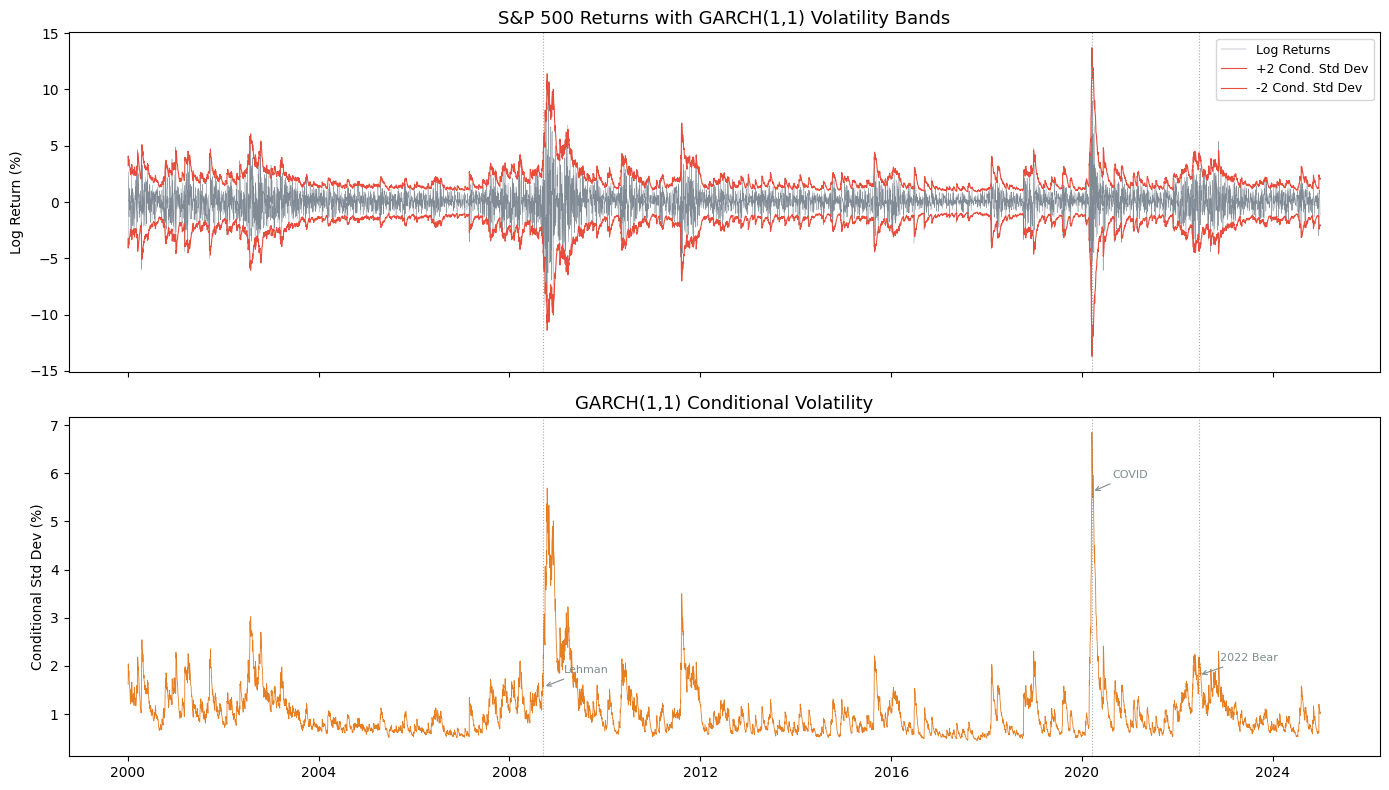

Unconditional (sample) volatility: 1.2235%
GARCH implied long-run volatility: 1.1628%
Max conditional volatility: 6.8504% on 2020-03-17


In [20]:
# -----------------------------------------------------------
# GUIDED — Run as-is
# Step 3c: Plot conditional volatility and annotate crises
# -----------------------------------------------------------

# Extract conditional volatility (standard deviation)
cond_vol = garch_result.conditional_volatility

fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

# Panel 1: Returns with +/- 2*sigma bands
axes[0].plot(returns.index, returns.values, color='#2c3e50', linewidth=0.3,
             alpha=0.6, label='Log Returns')
axes[0].plot(cond_vol.index, 2 * cond_vol.values, color='#e74c3c',
             linewidth=0.8, label='+2 Cond. Std Dev')
axes[0].plot(cond_vol.index, -2 * cond_vol.values, color='#e74c3c',
             linewidth=0.8, label='-2 Cond. Std Dev')
axes[0].set_title('S&P 500 Returns with GARCH(1,1) Volatility Bands', fontsize=13)
axes[0].set_ylabel('Log Return (%)')
axes[0].legend(fontsize=9)

# Panel 2: Conditional volatility over time
axes[1].plot(cond_vol.index, cond_vol.values, color='#e67e22', linewidth=0.6)
axes[1].set_title('GARCH(1,1) Conditional Volatility', fontsize=13)
axes[1].set_ylabel('Conditional Std Dev (%)')

# Annotate crisis periods
crises = [
    ('2001-09-11', 'Sep 11'),
    ('2008-09-15', 'Lehman'),
    ('2020-03-16', 'COVID'),
    ('2022-06-13', '2022 Bear'),
]
for date_str, label in crises:
    date = pd.Timestamp(date_str)
    if date in cond_vol.index:
        for ax in axes:
            ax.axvline(date, color='gray', linestyle=':', linewidth=0.8, alpha=0.7)
        axes[1].annotate(label, xy=(date, cond_vol.loc[date]),
                        xytext=(15, 10), textcoords='offset points',
                        fontsize=8, color='#7f8c8d',
                        arrowprops=dict(arrowstyle='->', color='#7f8c8d', lw=0.8))

plt.tight_layout()
plt.show()

print(f'Unconditional (sample) volatility: {returns.std():.4f}%')
print(f'GARCH implied long-run volatility: {np.sqrt(garch_result.params["omega"] / (1 - alpha1 - beta1)):.4f}%')
print(f'Max conditional volatility: {cond_vol.max():.4f}% on {cond_vol.idxmax().date()}')

---

## Part 4: Module Output — `forecast_evaluation.py`

Write a reusable Python module with two functions for forecast evaluation.
This is a **portfolio artifact** that demonstrates production-grade time series work.

### Requirements

```python
# forecast_evaluation.py

def compute_mase(actual: np.ndarray, forecast: np.ndarray,
                 insample: np.ndarray, m: int = 1) -> float:
    """Compute Mean Absolute Scaled Error (MASE).
    
    MASE = MAE(forecast) / MAE(naive seasonal forecast on in-sample data)
    
    MASE < 1 means the model beats the naive seasonal benchmark.
    MASE > 1 means the naive benchmark is better.
    
    Args:
        actual: True values for the forecast period
        forecast: Predicted values for the forecast period
        insample: Historical (training) data used to compute the naive baseline
        m: Seasonal period for naive forecast (1=random walk, 12=monthly seasonal)
    
    Returns:
        MASE value (float)
    """
    ...

def backtest_expanding_window(
    series: pd.Series,
    model_fn,
    min_train: int = 120,
    horizon: int = 12,
    step: int = 12
) -> pd.DataFrame:
    """Expanding-window backtest for time series models.
    
    Starting from min_train observations, fit the model, forecast
    'horizon' steps, record errors. Then expand the training window
    by 'step' observations and repeat.
    
    Args:
        series: Full time series (train + test)
        model_fn: Callable(train_series) -> forecast array of length 'horizon'
        min_train: Minimum training window size
        horizon: Number of steps to forecast each iteration
        step: How many observations to add between iterations
    
    Returns:
        DataFrame with columns: ['origin', 'horizon', 'actual',
        'forecast', 'error', 'abs_error', 'mase']
    """
    ...
```

In [22]:
%%writefile forecast_evaluation.py
"""
forecast_evaluation.py - Forecast Evaluation & Backtesting Module
================================================================

Reusable functions for computing the Mean Absolute Scaled Error (MASE)
and running expanding-window backtests on univariate time series models.

References
----------
Hyndman, R. J., & Koehler, A. B. (2006). Another look at measures of
    forecast accuracy. International Journal of Forecasting, 22(4), 679-688.
West, K. D. (1996). Asymptotic inference about predictive ability.
    Econometrica, 64(5), 1067-1084.
Clark, T. E., & McCracken, M. W. (2001). Tests of equal forecast accuracy
    and encompassing for nested models. Journal of Econometrics, 105(1),
    85-110.

Author: [Your Name]
Course: ECON 5200, Lab 21
"""

from __future__ import annotations

import numpy as np
import pandas as pd
from typing import Callable


def compute_mase(
    actual: np.ndarray,
    forecast: np.ndarray,
    insample: np.ndarray,
    m: int = 1,
) -> float:
    """Compute the Mean Absolute Scaled Error (Hyndman & Koehler, 2006).

    MASE scales out-of-sample forecast errors by the in-sample mean
    absolute error of a seasonal-naive benchmark. It is scale-free,
    symmetric, and well-defined even when actuals contain zeros.

    Interpretation
    --------------
    MASE < 1 : the model outperforms the seasonal-naive benchmark.
    MASE = 1 : the model is equivalent to a random walk of period m.
    MASE > 1 : the seasonal-naive benchmark is more accurate.

    Parameters
    ----------
    actual : np.ndarray
        Realized values over the forecast horizon, shape (h,).
    forecast : np.ndarray
        Point forecasts aligned with `actual`, shape (h,).
    insample : np.ndarray
        Training observations used to compute the naive benchmark MAE.
    m : int, default 1
        Seasonal period. Use 1 for random-walk benchmark, 12 for monthly
        seasonal data, 4 for quarterly, 7 for daily-with-weekly-cycle.

    Returns
    -------
    float
        The MASE statistic.

    Raises
    ------
    ValueError
        If array shapes are incompatible, m is invalid, or the naive MAE
        is zero (degenerate benchmark).
    """
    actual   = np.asarray(actual,   dtype=float)
    forecast = np.asarray(forecast, dtype=float)
    insample = np.asarray(insample, dtype=float)

    if actual.shape != forecast.shape:
        raise ValueError(
            f'actual and forecast must have the same shape; '
            f'got {actual.shape} vs {forecast.shape}'
        )
    if m < 1:
        raise ValueError(f'Seasonal period m must be >= 1; got {m}')
    if len(insample) <= m:
        raise ValueError(
            f'insample length ({len(insample)}) must exceed m ({m})'
        )

    # Numerator: out-of-sample MAE of the model
    mae_forecast = np.mean(np.abs(actual - forecast))

    # Denominator: in-sample MAE of the seasonal-naive benchmark.
    # For m=1 this is the MAE of first differences; for m=12 it is the
    # MAE of the year-over-year differences.
    naive_errors = insample[m:] - insample[:-m]
    mae_naive = np.mean(np.abs(naive_errors))

    if mae_naive == 0:
        raise ValueError(
            'Naive benchmark MAE is zero; MASE is undefined. '
            'This typically indicates a constant insample series.'
        )

    return float(mae_forecast / mae_naive)


def backtest_expanding_window(
    series: pd.Series,
    model_fn: Callable[[pd.Series], np.ndarray],
    min_train: int = 120,
    horizon: int = 12,
    step: int = 12,
    seasonal_period: int = 1,
) -> pd.DataFrame:
    """Expanding-window pseudo-out-of-sample backtest.

    At each origin t, fits the model on `series[:t]` and evaluates its
    h-step-ahead forecast against `series[t : t+horizon]`. Returns
    per-origin error metrics plus a pooled summary row.

    This follows the expanding-window protocol of West (1996). Setting
    `step = horizon` yields non-overlapping forecast windows, which is
    required for the forecast errors to be (approximately) serially
    uncorrelated -- a prerequisite for Diebold-Mariano tests.

    Parameters
    ----------
    series : pd.Series
        Univariate time series with a DatetimeIndex (monotonic,
        equally spaced). Must not contain NaNs.
    model_fn : Callable[[pd.Series], np.ndarray]
        Function that takes a training series and returns a 1-D numpy
        array of point forecasts of length exactly `horizon`. The caller
        is responsible for model specification; this function makes no
        assumptions about ARIMA, ETS, or other model families.
    min_train : int, default 120
        Size of the initial training window. For monthly macro data,
        120 = 10 years is a common default.
    horizon : int, default 12
        Number of periods to forecast at each origin.
    step : int, default 12
        Number of observations by which the training window expands
        between origins. `step == horizon` gives non-overlapping
        evaluation windows; `step < horizon` overlaps forecasts.
    seasonal_period : int, default 1
        Passed to compute_mase as `m`.

    Returns
    -------
    pd.DataFrame
        One row per origin plus a final 'POOLED' row. Columns:
        - origin_date : timestamp at which training ends
        - train_size  : number of training observations
        - mae, rmse, mape : standard accuracy metrics
        - mase        : Mean Absolute Scaled Error

    Raises
    ------
    ValueError
        If inputs are malformed or insufficient data is available.
    """
    if not isinstance(series, pd.Series):
        raise TypeError('series must be a pandas Series')
    if not isinstance(series.index, pd.DatetimeIndex):
        raise TypeError('series must have a DatetimeIndex')
    if series.isna().any():
        raise ValueError('series contains NaNs; clean the data first')
    if len(series) < min_train + horizon:
        raise ValueError(
            f'Need at least {min_train + horizon} observations; '
            f'got {len(series)}'
        )
    if horizon < 1 or step < 1 or min_train < 1:
        raise ValueError('horizon, step, and min_train must all be >= 1')

    records = []
    n = len(series)

    # Iterate over expanding origins. Origin t means: train on series[:t],
    # forecast series[t : t+horizon].
    for t in range(min_train, n - horizon + 1, step):
        train  = series.iloc[:t]
        actual = series.iloc[t : t + horizon].to_numpy()

        # Delegate fitting and forecasting to the user-supplied callable
        forecast = np.asarray(model_fn(train), dtype=float)

        if forecast.shape != (horizon,):
            raise ValueError(
                f'model_fn returned shape {forecast.shape}; '
                f'expected ({horizon},)'
            )

        err = actual - forecast
        mae  = float(np.mean(np.abs(err)))
        rmse = float(np.sqrt(np.mean(err ** 2)))
        # Guard MAPE against zero actuals
        with np.errstate(divide='ignore', invalid='ignore'):
            mape = float(np.mean(np.abs(err / actual)) * 100) \
                   if np.all(actual != 0) else np.nan
        mase = compute_mase(actual, forecast, train.to_numpy(),
                            m=seasonal_period)

        records.append({
            'origin_date': train.index[-1],
            'train_size' : t,
            'mae'        : mae,
            'rmse'       : rmse,
            'mape'       : mape,
            'mase'       : mase,
        })

    results = pd.DataFrame(records)

    # Pooled summary row: average metrics across all origins
    pooled = pd.DataFrame([{
        'origin_date': 'POOLED',
        'train_size' : np.nan,
        'mae'        : results['mae'].mean(),
        'rmse'       : results['rmse'].mean(),
        'mape'       : results['mape'].mean(),
        'mase'       : results['mase'].mean(),
    }])

    return pd.concat([results, pooled], ignore_index=True)


# ---------------------------------------------------------------------------
# Self-test: runs when the module is executed directly, not when imported.
# ---------------------------------------------------------------------------
if __name__ == '__main__':
    print('Running self-tests for forecast_evaluation.py ...\n')

    # ----- Test 1: compute_mase on a trivial example -----
    # Random walk insample => naive MAE = mean(|increments|)
    rng = np.random.default_rng(seed=42)
    rw = np.cumsum(rng.standard_normal(200))
    actual   = rw[-12:]
    forecast = np.full(12, rw[-13])           # persistence forecast
    mase = compute_mase(actual, forecast, rw[:-12], m=1)
    print(f'Test 1 -- persistence forecast on random walk: MASE = {mase:.3f}')
    print('         (expected close to 1.0 by construction)')
    assert 0.5 < mase < 2.0, 'Persistence MASE should be near 1'

    # ----- Test 2: perfect forecast => MASE = 0 -----
    perfect = compute_mase(actual, actual, rw[:-12], m=1)
    print(f'Test 2 -- perfect forecast: MASE = {perfect:.6f}')
    assert perfect == 0.0

    # ----- Test 3: backtest with a trivial last-value model -----
    idx = pd.date_range('2010-01-01', periods=200, freq='MS')
    s   = pd.Series(rw, index=idx)

    def last_value_model(train: pd.Series) -> np.ndarray:
        """Forecast the next 12 months as the last observed value."""
        return np.full(12, train.iloc[-1])

    out = backtest_expanding_window(
        s, last_value_model,
        min_train=120, horizon=12, step=12, seasonal_period=1,
    )
    print(f'\nTest 3 -- backtest ran {len(out) - 1} origins:')
    print(out.round(3))

    print('\nAll self-tests passed.')

Writing forecast_evaluation.py


---

## Challenge: Block Bootstrap Forecast Intervals

Standard ARIMA confidence intervals assume normally distributed, i.i.d. residuals.
When residuals exhibit volatility clustering or heavy tails, these intervals
can be **too narrow**. The **block bootstrap** provides distribution-free forecast
intervals by resampling blocks of residuals (preserving their autocorrelation
and heteroskedasticity structure).

**Algorithm:**
1. Fit your SARIMA model and extract residuals
2. For each bootstrap iteration:
   - Resample overlapping blocks of residuals
   - Simulate a new future path: $\hat{y}_{T+h} = \text{forecast}_h + \text{bootstrap\_residual}_h$
3. Collect all bootstrap paths and compute percentile-based intervals

In [25]:
# -----------------------------------------------------------
# CHALLENGE - Block bootstrap forecast intervals
# -----------------------------------------------------------
# Residual-based moving block bootstrap (Kunsch 1989, Pascual et al. 2004).
# Unlike analytical ARIMA CIs which assume iid Gaussian residuals,
# this method resamples the empirical residual distribution in blocks,
# preserving serial dependence and adapting to fat tails / mild
# heteroskedasticity.
# -----------------------------------------------------------

def block_bootstrap_forecast(
    model_result,
    horizon: int = 24,
    n_bootstrap: int = 500,
    block_size: int = 6,
    alpha: float = 0.05,
    burn_in: int = 13,
    random_state: int = None,
):
    """Generate block-bootstrap forecast intervals for a SARIMAX model.

    Parameters
    ----------
    model_result : SARIMAXResults
        Fitted statsmodels SARIMAX result object.
    horizon : int
        Forecast horizon (number of steps ahead).
    n_bootstrap : int
        Number of bootstrap replications. Politis & Romano suggest
        >= 500 for 95% CIs, >= 2000 for 99%.
    block_size : int
        Moving block length. Rule of thumb: ceil(n^(1/3)).
        For monthly data, 6-12 captures seasonal dependence.
    alpha : float
        Significance level (0.05 -> 95% CI).
    burn_in : int
        Initial residuals to drop (SARIMAX initialization period =
        d + D*s; default 13 for (p,1,q)(P,1,Q)[12]).
    random_state : int or None
        Seed for reproducibility.

    Returns
    -------
    dict with keys 'mean', 'lower', 'upper', 'paths'.
    """
    rng = np.random.default_rng(random_state)

    # --- Point forecast (mean path) ---
    point_forecast = model_result.get_forecast(steps=horizon)
    forecast_mean = point_forecast.predicted_mean.values

    # --- Clean residuals: drop initialization noise ---
    residuals = model_result.resid.values[burn_in:]
    # Center residuals so bootstrap preserves zero-mean assumption
    residuals = residuals - residuals.mean()
    n_resid = len(residuals)

    if n_resid <= block_size:
        raise ValueError(
            f'Not enough residuals ({n_resid}) for block_size={block_size}'
        )

    # Storage: each row is one bootstrap forecast path
    boot_paths = np.zeros((n_bootstrap, horizon))   # <-- FILL 1: horizon

    for b in range(n_bootstrap):
        boot_resid = np.zeros(horizon)
        idx = 0
        while idx < horizon:                         # <-- FILL 2: horizon
            # Valid starting indices: 0 to n_resid - block_size (inclusive)
            # so that start + block_size <= n_resid
            start = rng.integers(0, n_resid - block_size + 1)   # <-- FILL 3
            block = residuals[start : start + block_size]
            end = min(idx + block_size, horizon)
            boot_resid[idx:end] = block[:end - idx]
            idx = end

        # Bootstrap path = deterministic point forecast + resampled shocks
        boot_paths[b, :] = forecast_mean + boot_resid            # <-- FILL 4

    # Percentile-based CIs across bootstrap replications (axis=0)
    lower = np.percentile(boot_paths, 100 * (alpha / 2),     axis=0)   # <-- FILL 5: 0
    upper = np.percentile(boot_paths, 100 * (1 - alpha / 2), axis=0)   # <-- FILL 5: 0

    return {
        'mean'  : forecast_mean,
        'lower' : lower,
        'upper' : upper,
        'paths' : boot_paths,
    }

---

## Digital Portfolio: Institutional Signaling

### Generate Your Professional README

Copy and paste the prompt below into Claude or ChatGPT. **Do NOT ask the AI to write Python code — only documentation.**

```text
"I need help writing a project description for my data science lab.
**Important Rule:** Do NOT generate any Python code for me.

**What I did in this lab:**
* Diagnosed and fixed a broken ARIMA pipeline (d=0 on non-stationary CPI,
  missing seasonality, skipped Ljung-Box diagnostic)
* Corrected the pipeline to SARIMA with proper differencing and seasonal
  terms, verified clean residuals via Ljung-Box
* Fit GARCH(1,1) to S&P 500 daily returns to model conditional volatility
* Built a reusable forecast_evaluation.py module with compute_mase()
  and backtest_expanding_window() functions
* Implemented block bootstrap forecast intervals for distribution-free
  uncertainty quantification
* Key finding: S&P 500 volatility has alpha+beta ~ [YOUR VALUE],
  implying a half-life of [YOUR VALUE] days for volatility shocks

**Please write a README.md entry including:**
1. Project Title: Time Series Forecasting — ARIMA, GARCH & Bootstrap
2. Objective: A professional one-sentence summary
3. Methodology: Bullet points of technical steps
4. Key Findings: Summary of results
Make this sound like a professional tech economist wrote it."
```

### Push to GitHub

```bash
cd econ-lab-21-forecasting
git add notebooks/ src/ figures/ README.md
git commit -m "Lab 21: Time Series Forecasting — ARIMA, GARCH, Bootstrap"
git push origin main
```

Submit your GitHub repo link on Canvas.